## Imports

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

## Data Loading

In [6]:
train = pd.read_csv('../data/raw/train.csv', parse_dates=['Date'])
store = pd.read_csv('../data/raw/store.csv')

# Merge
df = train.merge(store, on='Store', how='left')

print(f"Shape: {df.shape}")
print(f"Period: {df['Date'].min()} -> {df['Date'].max()}")
print(f"# stores: {df['Store'].nunique()}")

Shape: (1017209, 18)
Period: 2013-01-01 00:00:00 -> 2015-07-31 00:00:00
# stores: 1115


## Basic Data Cleaning

In [9]:
# Only keep open days with sales > 0
df = df[(df['Open'] == 1) & (df['Sales'] > 0)].copy()

# Check missing values
missing = df.isnull().sum()
print("missing values :\n", missing[missing>0])

print(f"\n Shape after cleaning: {df.shape}")

missing values :
 CompetitionDistance            2186
CompetitionOpenSinceMonth    268600
CompetitionOpenSinceYear     268600
Promo2SinceWeek              423292
Promo2SinceYear              423292
PromoInterval                423292
dtype: int64

 Shape after cleaning: (844338, 18)


## Sales Distribution

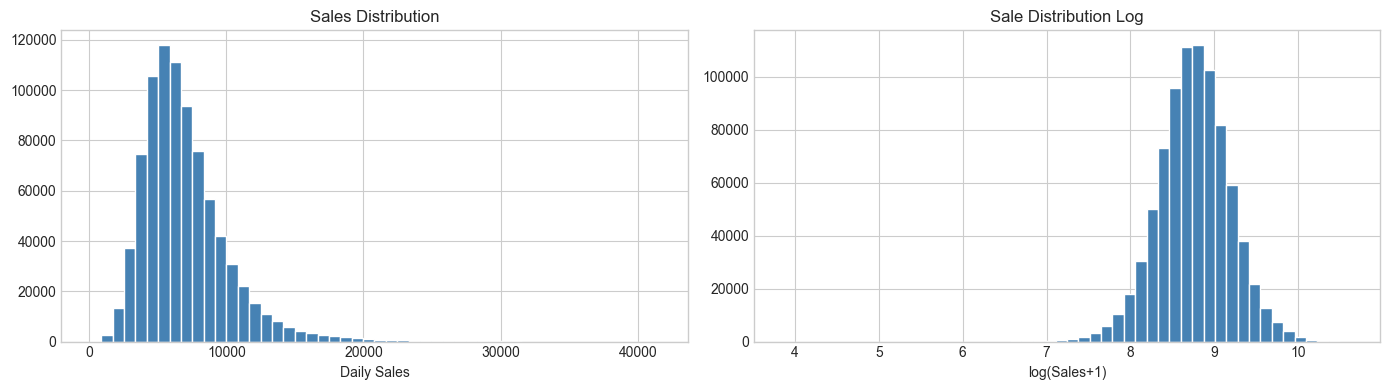

count    844338.000000
mean       6955.959134
std        3103.815515
min          46.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sales Distribution')
axes[0].set_xlabel('Daily Sales')

axes[1].hist(np.log1p(df['Sales']), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Sale Distribution Log')
axes[1].set_xlabel('log(Sales+1)')

plt.tight_layout()
plt.show()

print(df['Sales'].describe())

## Observations from EDA

- asymmetrical sales distribution (right-skewed)
- log(sales) follows a gaussian-like distribution
- Decision: train model on log sales, then transform data back to sales using exp()
- Why: penalizes systematically relative errors instead of absolute ones

## Seasonality

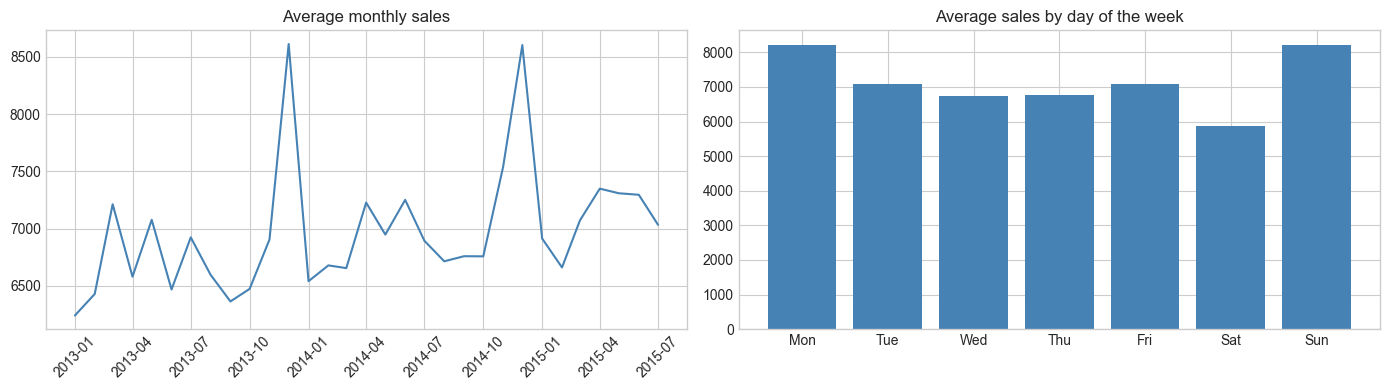

In [15]:
# Average monthly sales
monthly = df.groupby(df['Date'].dt.to_period('M'))['Sales'].mean().reset_index()
monthly['Date'] = monthly['Date'].dt.to_timestamp()

# Average sales by day of the week
dow = df.groupby('DayOfWeek')['Sales'].mean()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(monthly['Date'], monthly['Sales'], color='steelblue', linewidth=1.5)
axes[0].set_title('Average monthly sales')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(dow_labels, dow.values, color='steelblue')
axes[1].set_title('Average sales by day of the week')

plt.tight_layout()
plt.show()

## Promotion Effect

In [17]:
promo_impact = df.groupby('Promo')['Sales'].agg(['mean', 'median'])
promo_impact.index = ['Without promo', 'With promo']
print("Impact des promotions :\n", promo_impact)

lift = (promo_impact.loc['With promo', 'mean'] / promo_impact.loc['Without promo', 'mean'] - 1) * 100
print(f"\nLift moyen des promos : +{lift:.1f}%")

Impact des promotions :
                       mean  median
Without promo  5929.826183  5459.0
With promo     8228.739731  7650.0

Lift moyen des promos : +38.8%


## Store 1 Focus

Store 1 — 781 jours de données
Période : 2013-01-02 00:00:00 → 2015-07-31 00:00:00


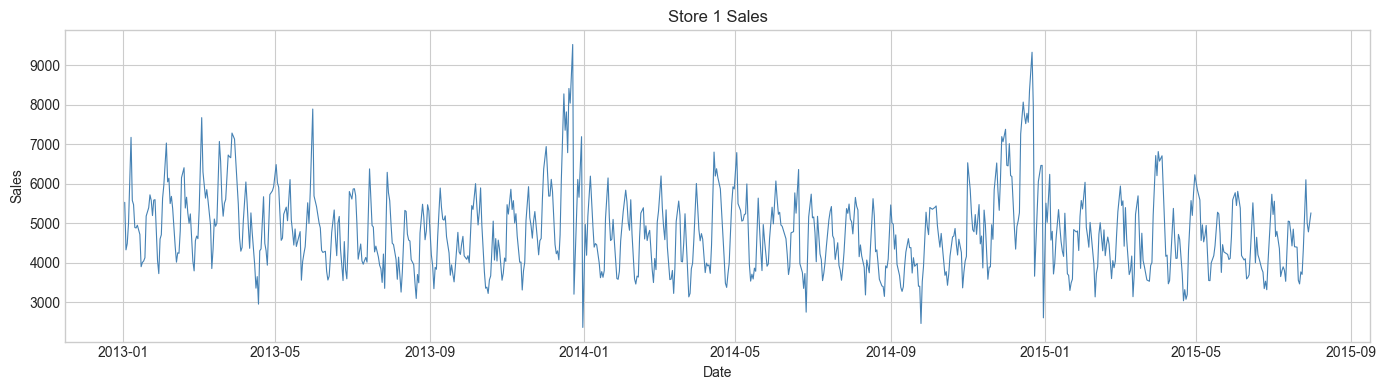

In [20]:
store_id = 1
df_store = df[df['Store'] == store_id].sort_values('Date').copy()

print(f"Store {store_id} — {len(df_store)} jours de données")
print(f"Période : {df_store['Date'].min()} → {df_store['Date'].max()}")

plt.figure(figsize=(14, 4))
plt.plot(df_store['Date'], df_store['Sales'], linewidth=0.8, color='steelblue')
plt.title(f'Store {store_id} Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

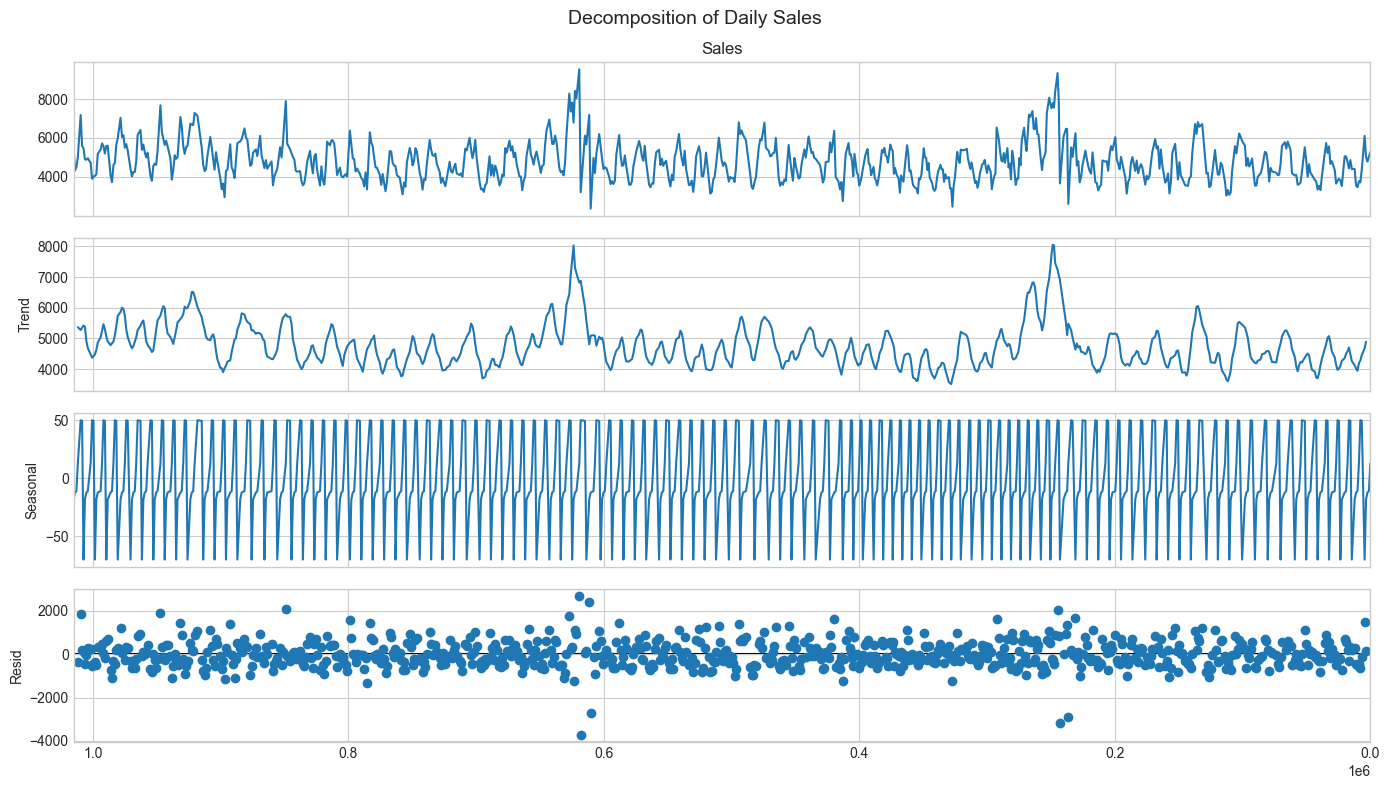

In [50]:
plt.rc("figure",figsize=(14, 8))
decomposition = seasonal_decompose(df_store['Sales'], model='additive', period=7)
decomposition.plot()
plt.suptitle('Decomposition of Daily Sales', fontsize=14)
plt.tight_layout()
plt.show()

## Naive Baseline

In [25]:
# train/test split with last 6 weeks for testing
cutoff = df_store['Date'].max() - pd.Timedelta(weeks=6)
train_df = df_store[df_store['Date'] <= cutoff].copy()
test_df = df_store[df_store['Date'] > cutoff].copy()

print(f"Train: {len(train_df)} days | Test: {len(test_df)} days")

# Baseline 1: average
mean_pred = train_df['Sales'].mean()
test_df['pred_mean'] = mean_pred

# Baseline 2: same day of the week average
dow_means = train_df.groupby('DayOfWeek')['Sales'].mean()
test_df['pred_dow'] = test_df['DayOfWeek'].map(dow_means)

# Metrics
mape_mean = mean_absolute_percentage_error(test_df['Sales'], test_df['pred_mean']) * 100
mape_dow = mean_absolute_percentage_error(test_df['Sales'], test_df['pred_dow']) * 100

print(f"\nOvereall average baseline — MAPE : {mape_mean:.1f}%")
print(f"Same day of the week average baseline  — MAPE : {mape_dow:.1f}%")

Train: 745 days | Test: 36 days

Overeall average baseline — MAPE : 17.3%
Same day of the week average baseline  — MAPE : 17.6%


## EDA & Baseline Sumup

In [27]:
summary = {
    'store_id': store_id,
    'train_days': len(train_df),
    'test_days': len(test_df),
    'train_period': f"{train_df['Date'].min().date()} → {train_df['Date'].max().date()}",
    'test_period': f"{test_df['Date'].min().date()} → {test_df['Date'].max().date()}",
    'sales_mean': round(df_store['Sales'].mean(), 0),
    'sales_std': round(df_store['Sales'].std(), 0),
    'promo_lift_pct': round(lift, 1),  # depuis cellule 6
    'baseline_mean_mape': round(mape_mean, 1),
    'baseline_dow_mape': round(mape_dow, 1),
}

for k, v in summary.items():
    print(f"{k:30s}: {v}")

store_id                      : 1
train_days                    : 745
test_days                     : 36
train_period                  : 2013-01-02 → 2015-06-19
test_period                   : 2015-06-20 → 2015-07-31
sales_mean                    : 4759.0
sales_std                     : 1012.0
promo_lift_pct                : 38.8
baseline_mean_mape            : 17.3
baseline_dow_mape             : 17.6
